In [1]:
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

import sys
sys.path.insert(0, '..')
from src.visualizer import plot_metrics_comparison, create_barh
from src.modelization import evaluate_model, trouver_seuil_optimal
from src.preprocessing import build_preprocessor

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("credit-scoring")

<Experiment: artifact_location='/home/rapha/ai-engineer/credit-scoring-mlops/mlruns', creation_time=1773648058682, experiment_id='1', last_update_time=1773648058682, lifecycle_stage='active', name='credit-scoring', tags={}, workspace='default'>

In [2]:
# Chargement des données prétraitées
df_train = pd.read_csv("../data/processed/train_processed.csv")

# Séparation features / cible
X = df_train.drop(columns=["TARGET", "SK_ID_CURR"])
y = df_train["TARGET"]

print(f"Features : {X.shape[1]} colonnes")
print(f"Échantillons : {X.shape[0]} lignes")
print(f"Distribution cible :\n{y.value_counts(normalize=True).round(3)}")


Features : 111 colonnes
Échantillons : 307511 lignes
Distribution cible :
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


In [3]:
# Sous-échantillon stratifié pour accélérer les tests (10% du dataset)
# Mettre MODE_TEST = False pour l'entraînement final sur tout le dataset
MODE_TEST = False

if MODE_TEST:
    _, X_sample, _, y_sample = train_test_split(
        X, y, test_size=0.1, stratify=y, random_state=42
    )
    print(f"Mode test — échantillon : {X_sample.shape[0]} lignes")
else:
    X_sample, y_sample = X, y
    print(f"Mode complet — {X_sample.shape[0]} lignes")

Mode complet — 307511 lignes


In [4]:
# Identification des types de colonnes
num_cols = X_sample.select_dtypes(include='number').columns.tolist()
cat_cols = X_sample.select_dtypes(include='object').columns.tolist()

# Preprocesseur commun à tous les modèles (construit via src/preprocessing.py)
preprocessor = build_preprocessor(num_cols, cat_cols)

print(f'Colonnes numériques   : {len(num_cols)}')
print(f'Colonnes catégorielles : {len(cat_cols)}')

Colonnes numériques   : 98
Colonnes catégorielles : 13


In [5]:
# Métriques de validation croisée utilisées pour tous les modèles
scoring = {
    'roc_auc': 'roc_auc',
    'recall':  'recall',
    'f1':      'f1',
}

# Split train/validation — le coût métier est calculé sur X_val (données non vues)
X_train, X_val, y_train, y_val = train_test_split(
    X_sample, y_sample, test_size=0.2, stratify=y_sample, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train : {X_train.shape[0]} lignes | Validation : {X_val.shape[0]} lignes")

Train : 246008 lignes | Validation : 61503 lignes


In [6]:
def evaluate_model_credit(name, pipeline, params):
    """Wrapper métier autour de evaluate_model.

    Ouvre le run MLflow, délègue l'entraînement et le logging générique à
    evaluate_model, puis ajoute les métriques spécifiques au projet :
    coût métier et seuil de décision optimal.
    """
    with mlflow.start_run(run_name=name):
        result = evaluate_model(
            name, pipeline, params,
            X_train, y_train, X_val,
            cv, scoring,
            dataset_source="../data/processed/train_processed.csv",
        )

        # Métriques métier
        seuil_opt, cout_opt = trouver_seuil_optimal(y_val, result['y_proba_val'])
        mlflow.log_metric('cout_metier',   cout_opt)
        mlflow.log_metric('seuil_optimal', seuil_opt)
        mlflow.set_tag("dataset", "full" if not MODE_TEST else "sample_10pct")

        summary = result['summary']
        auc    = round(summary['roc_auc']['test_mean'], 4)
        recall = round(summary['recall']['test_mean'],  4)
        f1     = round(summary['f1']['test_mean'],      4)
        print(f"[{name}] AUC={auc:.4f} | Recall={recall:.4f} | F1={f1:.4f} | Coût métier (seuil={seuil_opt})={cout_opt}")

In [7]:
# Définition des modèles à comparer : (nom_run, pipeline, params_mlflow)
modeles = [
    (
        'dummy_baseline',
        Pipeline([('preprocessor', preprocessor), ('clf', DummyClassifier(
            strategy='most_frequent', random_state=42
        ))]),
        {'model': 'DummyClassifier', 'strategy': 'most_frequent'},
    ),
    (
        'logistic_regression',
        Pipeline([('preprocessor', preprocessor), ('clf', LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=42
        ))]),
        {'model': 'LogisticRegression', 'class_weight': 'balanced'},
    ),
    (
        'random_forest',
        Pipeline([('preprocessor', preprocessor), ('clf', RandomForestClassifier(
            n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
        ))]),
        {'model': 'RandomForest', 'n_estimators': 100, 'class_weight': 'balanced'},
    ),
    (
        'xgboost',
        Pipeline([('preprocessor', preprocessor), ('clf', XGBClassifier(
            n_estimators=200, scale_pos_weight=9, random_state=42,
            n_jobs=-1, eval_metric='logloss', verbosity=0
        ))]),
        {'model': 'XGBoost', 'n_estimators': 200, 'scale_pos_weight': 9},
    ),
    (
        'lightgbm',
        Pipeline([('preprocessor', preprocessor), ('clf', LGBMClassifier(
            n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
        ))]),
        {'model': 'LightGBM', 'n_estimators': 200, 'class_weight': 'balanced'},
    ),
]

In [8]:
for nom, pipeline, params in modeles:
    evaluate_model_credit(nom, pipeline, params)


[dummy_baseline] Entraînement en cours...



/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See 

[dummy_baseline] AUC=0.5000 | Recall=0.0000 | F1=0.0000 | Coût métier (seuil=0.05)=49650

[logistic_regression] Entraînement en cours...



/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/03/17 22:14:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, wh

[logistic_regression] AUC=0.7585 | Recall=0.6841 | F1=0.2673 | Coût métier (seuil=0.53)=31840

[random_forest] Entraînement en cours...



...

[random_forest] AUC=0.7375 | Recall=0.0016 | F1=0.0032 | Coût métier (seuil=0.09)=33274

[xgboost] Entraînement en cours...



/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See 

[xgboost] AUC=0.7477 | Recall=0.4762 | F1=0.2974 | Coût métier (seuil=0.38)=32567

[lightgbm] Entraînement en cours...



/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature n

[lightgbm] AUC=0.7709 | Recall=0.6604 | F1=0.2875 | Coût métier (seuil=0.55)=30822


## Comparaison des résultats

In [9]:
DATASET_FILTER = "full" if not MODE_TEST else "sample_10pct"


# Récupération des runs MLflow de cette expérience
df_runs = mlflow.search_runs(experiment_names=["credit-scoring"])
df_runs = (
    df_runs[df_runs["tags.dataset"] == DATASET_FILTER]
    .sort_values("start_time", ascending=False)
    .head(5)
)

# Tableau récapitulatif
cols = {
    "tags.mlflow.runName":       "Modèle",
    "metrics.roc_auc_test_mean": "ROC-AUC",
    "metrics.recall_test_mean":  "Recall",
    "metrics.f1_test_mean":      "F1",
    "metrics.cout_metier":       "Coût métier",
    "metrics.seuil_optimal":     "Seuil optimal",
    "metrics.fit_time_final":    "Fit (s)",
    "metrics.predict_time_val":  "Predict (s)",
}
df_summary = (
    df_runs[list(cols.keys())]
    .rename(columns=cols)
    .set_index("Modèle")
    .sort_values("ROC-AUC", ascending=False)
    .round(4)
)
df_summary

,ROC-AUC,Recall,F1,Coût métier,Seuil optimal,Fit (s),Predict (s)
Modèle,,,,,,,
lightgbm,0.7709,0.6604,0.2875,30822.0,0.55,16.199,0.400
logistic_regression,0.7585,0.6841,0.2673,31840.0,0.53,11.368,0.364
xgboost,0.7477,0.4762,0.2974,32567.0,0.38,12.889,0.332
random_forest,0.7375,0.0016,0.0032,33274.0,0.09,28.791,0.706
dummy_baseline,0.5000,0.0000,0.0000,49650.0,0.05,4.852,0.320


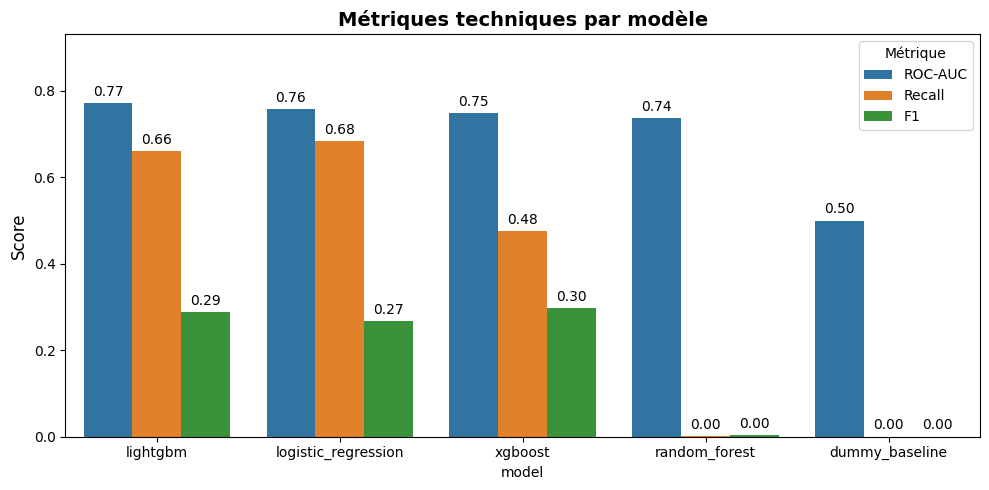

In [10]:
# Comparaison des métriques techniques (ROC-AUC, Recall, F1) par modèle
fig, ax = plt.subplots(figsize=(10, 5))

plot_metrics_comparison(
    df_summary[["ROC-AUC", "Recall", "F1"]],
    ax,
    metric_cols={"ROC-AUC": "ROC-AUC", "Recall": "Recall", "F1": "F1"},
    title="Métriques techniques par modèle",
    ylabel="Score",
)

plt.tight_layout()
plt.show()

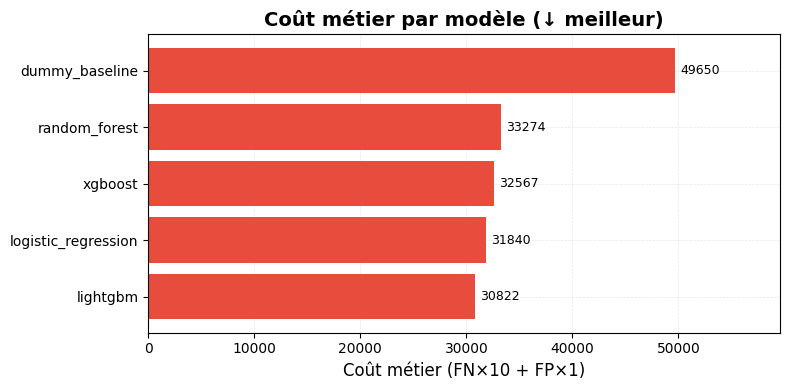

In [11]:
# Coût métier par modèle — critère de sélection principal (↓ meilleur)
fig, ax = plt.subplots(figsize=(8, 4))

df_cout = df_summary[["Coût métier"]].reset_index()
df_cout.columns = ["modele", "cout"]

create_barh(
    df_cout, ax,
    x="cout", y="modele",
    title="Coût métier par modèle (↓ meilleur)",
    xlabel="Coût métier (FN×10 + FP×1)",
    color="#e74c3c",
    fmt="{:.0f}",
)

plt.tight_layout()
plt.show()

## Choix du modèle final : LightGBM

Sur la base de la comparaison des 4 modèles, **LightGBM est retenu comme modèle champion**.

| Modèle | ROC-AUC | Recall | Coût métier |
|---|---|---|---|
| **LightGBM** | **0.7709** | 0.6604 | **30 822** |
| Logistic Regression | 0.7585 | 0.6841 | 31 840 |
| XGBoost | 0.7477 | 0.4762 | 32 567 |
| Random Forest | 0.7375 | 0.0016 | 33 274 |

### Justification

- **Meilleur ROC-AUC** (0.7709) : LightGBM discrimine mieux les bons et mauvais clients que tous les autres modèles, et reste dans la plage cible [0.75 – 0.82] qui écarte tout soupçon d'overfitting.
- **Coût métier le plus bas** (30 822) : c'est le critère de sélection principal. Le coût métier pondère les faux négatifs (FN × 10) bien plus que les faux positifs (FP × 1), car accorder un crédit à un mauvais client coûte bien plus cher que refuser un bon client.
- **Recall acceptable** (0.6604) : légèrement inférieur à la Régression Logistique (0.6841), mais cette différence minime est largement compensée par le meilleur coût métier global.

### Prochaine étape

Ce modèle sera enregistré dans le **MLflow Model Registry** puis optimisé dans le notebook `4_optimization.ipynb` (hyperparamètres + seuil de décision métier).

In [12]:
# Enregistrement du meilleur modèle (LightGBM) dans le Model Registry
runs = mlflow.search_runs(
    experiment_names=["credit-scoring"],
    filter_string="tags.mlflow.runName = 'lightgbm'",
    order_by=["start_time DESC"],
    max_results=1,
)
best_run_id = runs.iloc[0]["run_id"]
mlflow.register_model(f"runs:/{best_run_id}/model", "credit-scoring-model")
print(f"Modèle LightGBM enregistré dans le registry (run_id={best_run_id})")

Registered model 'credit-scoring-model' already exists. Creating a new version of this model...
2026/03/17 22:21:44 WARNING mlflow.tracking._model_registry.fluent: Run with id 1eb2d331762744ec935a74d274313346 has no artifacts at artifact path 'model', registering model based on models:/m-7046dd853ea643a0a66f9906a927bf94 instead


Modèle LightGBM enregistré dans le registry (run_id=1eb2d331762744ec935a74d274313346)


Created version '2' of model 'credit-scoring-model'.
